# Catalogues as Data: Pairwise Matching Pipeline
**James Baker, University of Southampton**

---

This notebook covers the data-preparation and matching stages of the pipeline:

1. **Setup** — configure paths and parameters
2. **Load and parse records** — extract structured data from individual XML files
3. **Feature extraction** — derive knowledge-labour features for each record
4. **Exploratory feature analysis** — understand the shape of the catalogue data
5. **Pairwise matching** — compare description text between all record pairs

**Outputs**:
- `derived-data/pairwise_{dataset}_{datetime}.tsv` — all pairs with SM ratio ≥ WRITE_THRESHOLD
- `derived-data/features_{dataset}_{datetime}.tsv` — per-record knowledge-labour features
- `visualisations/feature-distributions_{dataset}_{datetime}.png` — exploratory plots

These files are the inputs for `community_analysis_v3.ipynb`.

---

### Key methodological choice

This notebook extracts and compares **description-only text** — the content of all free-text
description fields — rather than comparing raw XML strings or full record content. This focuses
the comparison on the language used by cataloguers to write about items, not on the items
themselves or on shared structural markup. The practical effect is that records with similar
descriptive language are surfaced as similar regardless of what they describe — isolating
the signal of cataloguing practice from the signal of subject matter.

## 1. Setup

Configure file paths and parameters here. `RECORDS_DIR` should point to a directory of
individual per-record files produced by your data preparation step. To run on a different
dataset or sample, change this path — all output filenames update automatically to reflect
the dataset name and the exact time of the run.

Output files are written to `derived-data/` (tabular data) and `visualisations/` (figures),
both subdirectories of `code/`. These directories are created automatically if they do not
exist. File naming convention: `{step}_{dataset}_{YYYYMMDD-HHMMSS}.{ext}`

In [1]:
import os
import datetime

# ── Path configuration ─────────────────────────────────────────────────────────
# Directory containing individual per-record files (one file per catalogue record).
# Change this path to run on a different dataset or sample.
RECORDS_DIR = '../data/nls-moving-image-archive-2025/individual_records'

# ── Output directories ─────────────────────────────────────────────────────────
DERIVED_DATA_DIR = 'derived-data'
VIS_DIR          = 'visualisations'
os.makedirs(DERIVED_DATA_DIR, exist_ok=True)
os.makedirs(VIS_DIR, exist_ok=True)

# ── Colour-blind friendly palette (Okabe-Ito, 8 colours) ──────────────────────
# Use PALETTE for categorical data (groups, communities, series).
# Use plt.cm.viridis or plt.cm.plasma for sequential / continuous data (heatmaps).
PALETTE = [
    '#E69F00',  # orange
    '#56B4E9',  # sky blue
    '#009E73',  # bluish green
    '#F0E442',  # yellow
    '#0072B2',  # blue
    '#D55E00',  # vermillion
    '#CC79A7',  # reddish purple
    '#000000',  # black
]

# ── Automatic output filenames ─────────────────────────────────────────────────
# Filename encodes: step name + dataset name + run datetime (to the second).
# Running the notebook twice on the same dataset produces distinct files.
DATASET_NAME = os.path.basename(os.path.normpath(RECORDS_DIR))       # e.g. 'sample_500'
RUN_DATETIME = datetime.datetime.now().strftime('%Y%m%d-%H%M%S')      # e.g. '20260313-143022'

PAIRWISE_TSV = os.path.join(DERIVED_DATA_DIR, f'pairwise_{DATASET_NAME}_{RUN_DATETIME}.tsv')
FEATURES_TSV = os.path.join(DERIVED_DATA_DIR, f'features_{DATASET_NAME}_{RUN_DATETIME}.tsv')

# ── Pairwise matching parameters ───────────────────────────────────────────────
# QUICK_THRESHOLD: fast upper-bound pre-filter. Pairs below this are skipped
# without computing the full SM ratio. Keep at or below WRITE_THRESHOLD.
QUICK_THRESHOLD = 0.15

# WRITE_THRESHOLD: minimum SM ratio written to TSV. Keep low (0.2–0.3) so
# that the graph threshold in the analysis notebook can be tuned later
# without re-running the expensive pairwise computation.
WRITE_THRESHOLD = 0.2

# ── Scale mode ──────────────────────────────────────────────────────────────
# USE_LSH: True  → MinHash LSH pre-filter (recommended for > ~2,000 records).
#                  Builds candidate pairs in ~20s, then runs exact SM only on
#                  candidates. Estimated runtime for 23k records: 60–120 min.
#          False → full O(n²) comparison (fine for ≤ ~1,000 records; becomes
#                  prohibitive above ~2,000).  Estimated for 23k records: 70h+.
USE_LSH = True

# LSH parameters (only used when USE_LSH = True):
#   LSH_THRESHOLD : Jaccard (character-5gram) threshold for candidate pairs.
#                   Lower → more candidates, higher recall, slower.
#                   0.15–0.20 works well for catalogue descriptions.
#   NUM_PERM      : MinHash permutations. Higher → more accurate, slower build.
#                   128 is a good default; reduce to 64 for very large datasets.
LSH_THRESHOLD = 0.15
NUM_PERM      = 128

print(f"Records directory : {os.path.abspath(RECORDS_DIR)}")
print(f"Dataset name      : {DATASET_NAME}")
print(f"Run datetime      : {RUN_DATETIME}")
print(f"Pairwise output   : {os.path.abspath(PAIRWISE_TSV)}")
print(f"Features output   : {os.path.abspath(FEATURES_TSV)}")
print(f"Quick threshold   : {QUICK_THRESHOLD}")
print(f"Write threshold   : {WRITE_THRESHOLD}")

Records directory : /mnt/c/Users/jwb1n21/Dropbox/root/Southampton/Projects/ERC/data/nls-moving-image-archive-2025/individual_records
Dataset name      : individual_records
Run datetime      : 20260313-120649
Pairwise output   : /mnt/c/Users/jwb1n21/Dropbox/root/Southampton/Projects/ERC/code/derived-data/pairwise_individual_records_20260313-120649.tsv
Features output   : /mnt/c/Users/jwb1n21/Dropbox/root/Southampton/Projects/ERC/code/derived-data/features_individual_records_20260313-120649.tsv
Quick threshold   : 0.15
Write threshold   : 0.2


## 2. Load and parse records

Each record is stored as a self-contained text file named by its identifier. The parser extracts
Dublin Core field values from each file into a list of dictionaries. The fields extracted here
are chosen to support both the pairwise matching (description text) and the knowledge-labour
feature analysis (structural and bibliographic metadata).

If your catalogue data uses a different XML schema or file format, this is the cell to adapt.
The downstream steps only require two things from this stage: a unique record identifier
(`film_ref`) and the free-text description content (`descriptions`) for matching.

In [2]:
import xml.etree.ElementTree as ET
import pandas as pd
import re
import time

RDF_NS = 'http://www.w3.org/1999/02/22-rdf-syntax-ns#'
DC_NS  = 'http://purl.org/dc/terms/'
NS     = {'rdf': RDF_NS, 'dcterms': DC_NS}

def parse_record(filepath):
    """Parse a single-record XML file and return a dict of field values."""
    tree = ET.parse(filepath)
    desc = tree.getroot()

    def get(tag):
        el = desc.find(f'dcterms:{tag}', NS)
        return el.text.strip() if el is not None and el.text else None

    def get_all(tag):
        return [el.text.strip() for el in desc.findall(f'dcterms:{tag}', NS)
                if el.text and el.text.strip()]

    identifiers = get_all('identifier')
    film_ref    = next((i for i in identifiers if i.startswith('(filmRef)')), None)

    return {
        'film_ref'    : film_ref,
        'title'       : get('title'),
        'date'        : get('date'),
        'format'      : get('format'),
        'extent'      : get('extent'),
        'language'    : get('language'),
        'creators'    : get_all('creator'),
        'subjects'    : get_all('subject'),
        'descriptions': get_all('description'),
    }

record_files = sorted(
    f for f in os.listdir(RECORDS_DIR)
    if f.endswith('.txt') and f != 'base_data.txt'
)

n_files    = len(record_files)
CHECKPOINT = 500   # print a progress line every this many files

print(f'Found {n_files:,} record files in: {os.path.abspath(RECORDS_DIR)}')
print(f'Progress checkpoint every {CHECKPOINT} files.')
print(f"{'─'*60}")

records = []
t_start = time.time()
t_last  = t_start

for i, fname in enumerate(record_files):
    records.append(parse_record(os.path.join(RECORDS_DIR, fname)))

    if (i + 1) % CHECKPOINT == 0 or (i + 1) == n_files:
        t_now     = time.time()
        elapsed   = t_now - t_start
        rate      = (i + 1) / elapsed
        remaining = (n_files - (i + 1)) / rate if rate > 0 else 0
        pct       = (i + 1) / n_files * 100
        chunk_s   = t_now - t_last
        t_last    = t_now
        print(
            f'  [{i+1:>6,}/{n_files:,}]  {pct:5.1f}%  '
            f'elapsed {elapsed:6.1f}s  '
            f'rate {rate:6.1f} files/s  '
            f'ETA {remaining:5.0f}s  '
            f'(last {CHECKPOINT} files: {chunk_s:.1f}s)'
        )

print(f"{'─'*60}")
print(f'Loaded {len(records):,} records in {time.time()-t_start:.1f}s total.')
print()
print('Example record (first):')
for k, v in records[0].items():
    print(f'  {k}: {v[:3] if isinstance(v, list) else repr(v)}'
          f"{'...' if isinstance(v, list) and len(v) > 3 else ''}")


Found 23,491 record files in: /mnt/c/Users/jwb1n21/Dropbox/root/Southampton/Projects/ERC/data/nls-moving-image-archive-2025/individual_records
Progress checkpoint every 500 files.
────────────────────────────────────────────────────────────
  [   500/23,491]    2.1%  elapsed    5.1s  rate   97.8 files/s  ETA   235s  (last 500 files: 5.1s)
  [ 1,000/23,491]    4.3%  elapsed   10.2s  rate   98.1 files/s  ETA   229s  (last 500 files: 5.1s)
  [ 1,500/23,491]    6.4%  elapsed   17.0s  rate   88.0 files/s  ETA   250s  (last 500 files: 6.8s)
  [ 2,000/23,491]    8.5%  elapsed   39.3s  rate   50.9 files/s  ETA   423s  (last 500 files: 22.3s)
  [ 2,500/23,491]   10.6%  elapsed   64.9s  rate   38.5 files/s  ETA   545s  (last 500 files: 25.6s)
  [ 3,000/23,491]   12.8%  elapsed   89.4s  rate   33.5 files/s  ETA   611s  (last 500 files: 24.6s)
  [ 3,500/23,491]   14.9%  elapsed  113.8s  rate   30.7 files/s  ETA   650s  (last 500 files: 24.4s)
  [ 4,000/23,491]   17.0%  elapsed  137.7s  rate   29.1

## 3. Feature extraction

Each record is characterised by **knowledge-labour features** — properties that reflect cataloguer
choices and conventions rather than the content of the catalogued item. These features are the
analytical backbone of the community characterisation step: they let us ask whether detected
communities differ in *how* records are written, not just *what* they are about.

Features fall into three categories:
- **Volume**: how much description is present (word count, number of fields)
- **Convention**: which structural devices are used (shotlists, timecodes, credit lines)
- **Vocabulary**: how controlled-vocabulary indexing is applied (number of subject headings)

The `genre_tag` is extracted from the first description field, which in many moving-image
cataloguing traditions carries a controlled genre or type term. In other catalogue traditions
this field may carry different kinds of information; inspect your data to verify what it contains.

| Feature | What it measures |
|---|---|
| `desc_word_count` | Total words across all description fields — proxy for labour invested |
| `n_desc_fields` | Number of separate description fields — structural choice |
| `genre_tag` | First description field (controlled vocabulary genre or type term) |
| `has_shotlist` | Whether a SHOTLIST section is present — a moving-image cataloguing convention |
| `has_credit_line` | Whether a credit line in square brackets is present |
| `n_subjects` | Number of subject headings — depth of controlled vocabulary indexing |
| `year` | Year from date field — proxy for cataloguing era |
| `has_timecodes` | Whether timecodes appear in the description |
| `timecode_count` | Number of timecodes — measure of shotlist detail |

In [3]:
TIMECODE_RE = re.compile(r'\(\d*\.\d+\)')
CREDIT_RE   = re.compile(r'\[([^\]]+)\]')
YEAR_RE     = re.compile(r'\b(1[89]\d{2}|20[012]\d)\b')

def extract_features(rec):
    descriptions = rec['descriptions']
    full_desc    = ' '.join(descriptions)
    genre_raw    = descriptions[0].strip() if descriptions else ''
    genre_norm   = genre_raw.lower().strip('; ')
    has_shotlist = 'SHOTLIST' in full_desc
    has_reels    = bool(re.search(r'\bREEL\b', full_desc))
    credit_match = CREDIT_RE.search(full_desc)
    credit_text  = credit_match.group(1).strip() if credit_match else None
    timecodes    = TIMECODE_RE.findall(full_desc)
    year = None
    if rec['date']:
        m = YEAR_RE.search(rec['date'])
        if m:
            year = int(m.group(1))
    return {
        'film_ref'         : rec['film_ref'],
        'title'            : rec['title'],
        'year'             : year,
        'genre_tag'        : genre_norm,
        'genre_tag_raw'    : genre_raw,
        'desc_word_count'  : len(full_desc.split()),
        'n_desc_fields'    : len(descriptions),
        'has_shotlist'     : has_shotlist,
        'has_reels'        : has_reels,
        'has_credit_line'  : credit_text is not None,
        'credit_text'      : credit_text,
        'n_subjects'       : len(rec['subjects']),
        'has_timecodes'    : len(timecodes) > 0,
        'timecode_count'   : len(timecodes),
        'n_creators'       : len(rec['creators']),
        'description_text' : full_desc,
    }

print(f'Extracting knowledge-labour features for {len(records):,} records...')
t0          = time.time()
features    = [extract_features(r) for r in records]
features_df = pd.DataFrame(features)
elapsed     = time.time() - t0

print(f'Done in {elapsed:.1f}s.')
print(f'  Records with descriptions : {features_df["n_desc_fields"].gt(0).sum():,}')
print(f'  Records with shotlists    : {features_df["has_shotlist"].sum():,}')
print(f'  Records with timecodes    : {features_df["has_timecodes"].sum():,}')
yr = features_df['year'].dropna()
print(f'  Year range                : {int(yr.min())} \u2013 {int(yr.max())}')
print(f'  Median word count         : {features_df["desc_word_count"].median():.0f}')

# Save features (excluding large text column)
features_df.drop(columns=['description_text']).to_csv(FEATURES_TSV, sep='\t', index=False)
print(f'\nSaved features to: {os.path.abspath(FEATURES_TSV)}')
features_df.drop(columns=['description_text', 'credit_text', 'title']).describe(include='all').T


Extracting knowledge-labour features for 23,491 records...
Done in 0.4s.
  Records with descriptions : 23,473
  Records with shotlists    : 17,174
  Records with timecodes    : 10,692
  Year range                : 1895 – 2023
  Median word count         : 94

Saved features to: /mnt/c/Users/jwb1n21/Dropbox/root/Southampton/Projects/ERC/code/derived-data/features_individual_records_20260313-120649.tsv


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
film_ref,23491,23491,(filmRef)0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,17782.0,NaN,NaN,NaN,1975.140142,23.90136,1895.0,1959.0,1973.0,1994.0,2023.0
genre_tag,23491,673,non-fiction,11440,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genre_tag_raw,23491,720,non-fiction,11132,NaN,NaN,NaN,NaN,NaN,NaN,NaN
desc_word_count,23491.0,NaN,NaN,NaN,171.920608,200.279098,0.0,47.0,94.0,223.0,4574.0
n_desc_fields,23491.0,NaN,NaN,NaN,3.601762,0.848896,0.0,3.0,4.0,4.0,5.0
has_shotlist,23491,2,True,17174,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_reels,23491,2,False,23191,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_credit_line,23491,2,True,14019,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_subjects,23491.0,NaN,NaN,NaN,0.965902,1.75919,0.0,0.0,0.0,1.0,20.0


## 4. Exploratory feature analysis

Before running pairwise comparison, inspect the distribution of knowledge-labour features across
the dataset. This serves two purposes: (1) it confirms the parser extracted the expected fields
correctly, and (2) it gives an early sense of whether the data has sufficient variation to support
community detection. A catalogue where every record has the same word count, the same genre tag,
and the same conventions will not yield interesting communities; feature variation is a prerequisite.

Look for: the spread of description lengths (a bimodal distribution may signal two distinct
cataloguing traditions within the dataset); the prevalence of structural conventions such as
shotlists; and the temporal spread of records. Features that show high variation are likely
to drive community structure.

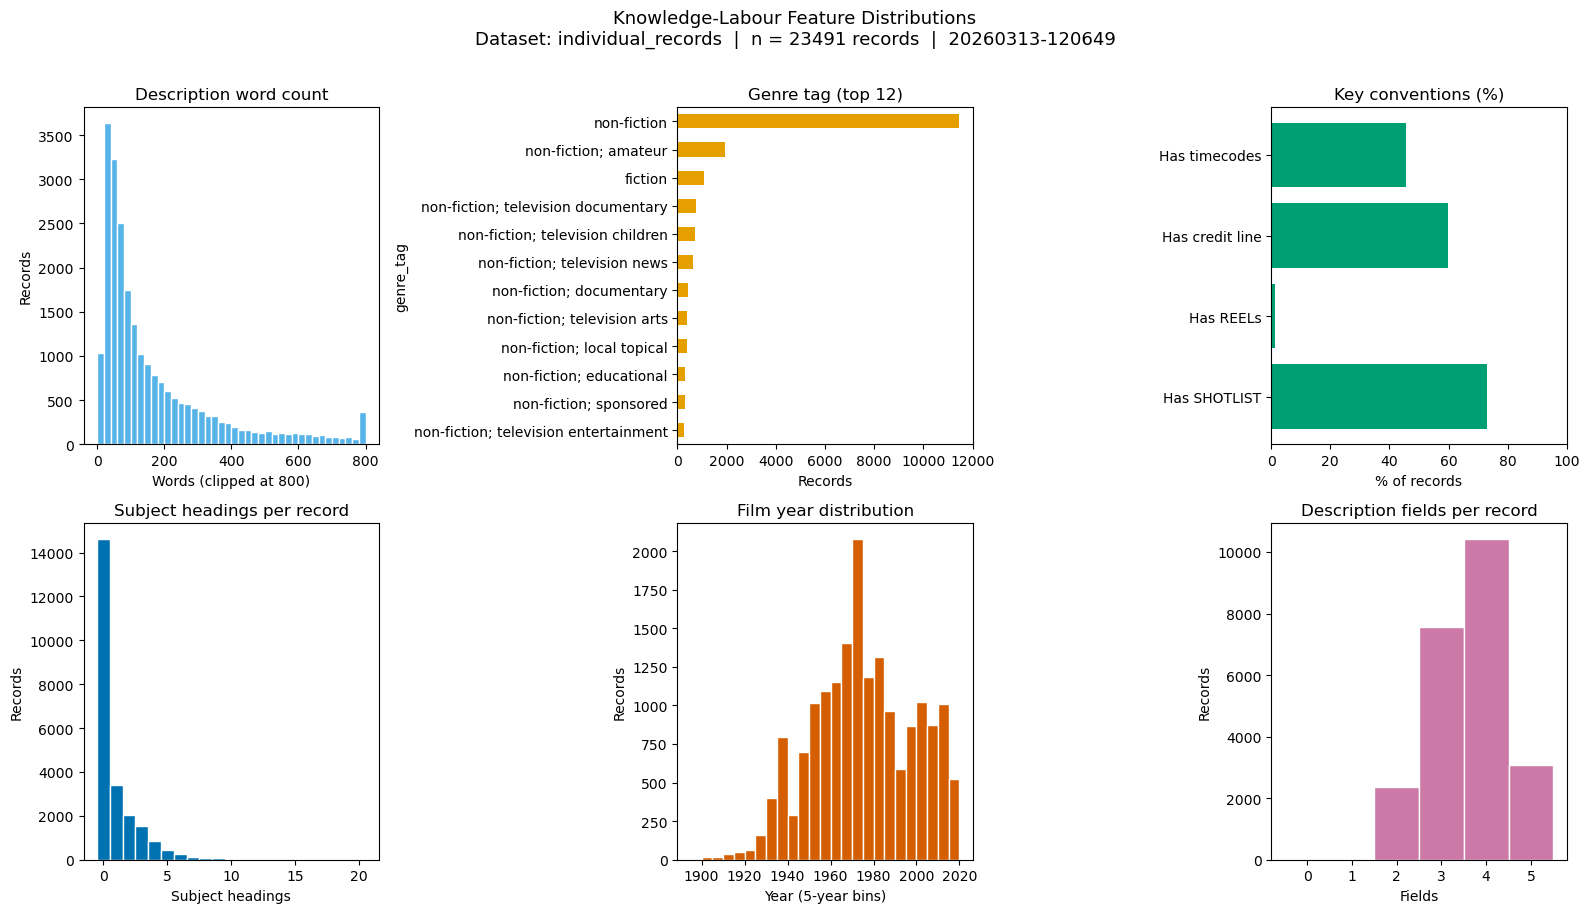

Saved to: /mnt/c/Users/jwb1n21/Dropbox/root/Southampton/Projects/ERC/code/visualisations/feature-distributions_individual_records_20260313-120649.png


In [4]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(
    f'Knowledge-Labour Feature Distributions\n'
    f'Dataset: {DATASET_NAME}  |  n = {len(features_df)} records  |  {RUN_DATETIME}',
    fontsize=13, y=1.01
)

ax = axes[0, 0]
ax.hist(features_df['desc_word_count'].clip(upper=800), bins=40,
        color=PALETTE[1], edgecolor='white')
ax.set_title('Description word count')
ax.set_xlabel('Words (clipped at 800)')
ax.set_ylabel('Records')

ax = axes[0, 1]
features_df['genre_tag'].value_counts().head(12).plot(kind='barh', ax=ax, color=PALETTE[0])
ax.set_title('Genre tag (top 12)')
ax.set_xlabel('Records')
ax.invert_yaxis()

ax = axes[0, 2]
bool_cols   = ['has_shotlist', 'has_reels', 'has_credit_line', 'has_timecodes']
bool_labels = ['Has SHOTLIST', 'Has REELs', 'Has credit line', 'Has timecodes']
ax.barh(bool_labels, [features_df[c].mean() * 100 for c in bool_cols], color=PALETTE[2])
ax.set_title('Key conventions (%)')
ax.set_xlabel('% of records')
ax.set_xlim(0, 100)

ax = axes[1, 0]
ax.hist(features_df['n_subjects'], bins=range(0, features_df['n_subjects'].max() + 2),
        color=PALETTE[4], edgecolor='white', align='left')
ax.set_title('Subject headings per record')
ax.set_xlabel('Subject headings')
ax.set_ylabel('Records')

ax = axes[1, 1]
years = features_df['year'].dropna()
ax.hist(years, bins=range(int(years.min()), int(years.max()) + 2, 5),
        color=PALETTE[5], edgecolor='white')
ax.set_title('Film year distribution')
ax.set_xlabel('Year (5-year bins)')
ax.set_ylabel('Records')

ax = axes[1, 2]
ax.hist(features_df['n_desc_fields'], bins=range(0, features_df['n_desc_fields'].max() + 2),
        color=PALETTE[6], edgecolor='white', align='left')
ax.set_title('Description fields per record')
ax.set_xlabel('Fields')
ax.set_ylabel('Records')

plt.tight_layout()
plot_path = os.path.join(VIS_DIR, f'feature-distributions_{DATASET_NAME}_{RUN_DATETIME}.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {os.path.abspath(plot_path)}")

## 5. Pairwise matching

Every record pair is compared using `difflib.SequenceMatcher`. The comparison uses only the
free-text description content, stripping out structural markup and controlled-vocabulary fields.
This isolates the language of description — the choices cataloguers made in writing about items —
from incidental structural similarity.

**Why SequenceMatcher?** Unlike word-overlap metrics (Jaccard, cosine TF-IDF), SequenceMatcher
rewards shared *sequences* of text, not just shared vocabulary. Two records that share a stock
phrase, a genre formula, or a structural opener will score high even if the rest of their
descriptions are different. This makes it sensitive to the kind of trained conventions and
formulaic language that cataloguing practice tends to produce.

**Threshold architecture**:
- `QUICK_THRESHOLD` — fast upper-bound pre-filter: pairs below this are skipped before computing
  the full SM ratio, greatly reducing computation time. Set at or below `WRITE_THRESHOLD`.
- `WRITE_THRESHOLD` — minimum ratio written to TSV. Keep this low (0.2–0.3) so that the graph
  construction threshold in `community_analysis_v6.ipynb` can be tuned later without re-running
  this computation. The pairwise step is the expensive one; calibration happens downstream.

> **Runtime**: approximately 1–3 minutes for 500 records (~125k pairs). For datasets of tens
> of thousands of records, use HPC or Google Colab (see notes at foot of notebook).

In [5]:
import difflib
import time

records_for_matching = [
    (row['film_ref'], row['description_text'])
    for _, row in features_df.iterrows()
]
desc_lookup = {ref: txt for ref, txt in records_for_matching}

n           = len(records_for_matching)
total_pairs = n * (n - 1) // 2
print(f"{'='*60}")
print(f'Records          : {n:,}')
print(f'Total pairs (n\u00b2) : {total_pairs:,}')
lsh_mode = "MinHash LSH (fast)" if USE_LSH else "O(n²) full comparison (slow)"
print(f"Mode             : {lsh_mode}")
print(f'Write threshold  : {WRITE_THRESHOLD}')
print(f'Output           : {os.path.abspath(PAIRWISE_TSV)}')
print(f"{'='*60}")

if USE_LSH:
    # ── MinHash LSH path ──────────────────────────────────────────────────────
    try:
        from datasketch import MinHash, MinHashLSH
    except ImportError:
        import subprocess, sys
        print('datasketch not found — installing...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                               'datasketch', '-q', '--break-system-packages'])
        from datasketch import MinHash, MinHashLSH
        print('datasketch installed.')

    import re as _re

    def make_shingles(text, k=5):
        text = _re.sub(r'\s+', ' ', text.lower().strip())
        return [text[i:i+k].encode('utf-8') for i in range(len(text) - k + 1)]

    # ── Phase 1: build MinHash signatures ────────────────────────────────────
    SIGN_CHECKPOINT = 2000
    print(f'\nPhase 1 \u2014 Building MinHash signatures (num_perm={NUM_PERM})')
    print(f'  checkpoint every {SIGN_CHECKPOINT:,} records')
    print(f"{'─'*60}")
    t0          = time.time()
    t_last      = t0
    lsh         = MinHashLSH(threshold=LSH_THRESHOLD, num_perm=NUM_PERM)
    minhashes   = {}
    empty_count = 0

    for idx, (film_ref, desc) in enumerate(records_for_matching):
        shingles = make_shingles(desc)
        if not shingles:
            empty_count += 1
            continue
        m = MinHash(num_perm=NUM_PERM)
        for s in shingles:
            m.update(s)
        minhashes[film_ref] = m
        lsh.insert(film_ref, m)

        if (idx + 1) % SIGN_CHECKPOINT == 0 or (idx + 1) == n:
            t_now     = time.time()
            elapsed   = t_now - t0
            rate      = (idx + 1) / elapsed
            remaining = (n - (idx + 1)) / rate if rate > 0 else 0
            chunk_s   = t_now - t_last
            t_last    = t_now
            print(
                f'  [{idx+1:>6,}/{n:,}]  {(idx+1)/n*100:5.1f}%  '
                f'elapsed {elapsed:5.1f}s  '
                f'rate {rate:6.1f} rec/s  '
                f'ETA {remaining:5.0f}s  '
                f'(last {SIGN_CHECKPOINT}: {chunk_s:.1f}s)'
            )

    t1 = time.time()
    print(f"{'─'*60}")
    print(f'  Built {len(minhashes):,} signatures in {t1-t0:.1f}s  '
          f'({empty_count} empty-description records skipped)')

    # ── Phase 2: query LSH for candidate pairs ────────────────────────────────
    print(f'\nPhase 2 \u2014 Querying LSH for candidate pairs (Jaccard \u2265 {LSH_THRESHOLD})')
    candidate_pairs = set()
    for film_ref, m in minhashes.items():
        for other in lsh.query(m):
            if other != film_ref:
                candidate_pairs.add(tuple(sorted([film_ref, other])))
    t2      = time.time()
    n_cands = len(candidate_pairs)
    print(f'  {n_cands:,} candidate pairs found in {t2-t1:.1f}s  '
          f'({n_cands/total_pairs*100:.3f}% of all {total_pairs:,} pairs)')

    # ── Phase 3: exact SM ratio on candidates ────────────────────────────────
    SM_CHECKPOINT = max(10_000, n_cands // 20)   # ~20 progress lines across the run
    print(f'\nPhase 3 \u2014 Exact SM ratio on {n_cands:,} candidate pairs')
    print(f'  checkpoint every {SM_CHECKPOINT:,} pairs')
    print(f"{'─'*60}")
    written       = 0
    skipped_ratio = 0
    t3            = time.time()
    t_last        = t3

    with open(PAIRWISE_TSV, 'w', encoding='utf-8') as out:
        out.write('base_id\tcompare_id\tsm_ratio\tdesc_len_base\tdesc_len_compare\n')
        for k, (base_id, compare_id) in enumerate(sorted(candidate_pairs)):
            if k > 0 and (k % SM_CHECKPOINT == 0 or k == n_cands - 1):
                t_now     = time.time()
                elapsed   = t_now - t3
                rate      = k / elapsed if elapsed > 0 else 0
                remaining = (n_cands - k) / rate if rate > 0 else 0
                chunk_s   = t_now - t_last
                t_last    = t_now
                print(
                    f'  [{k:>8,}/{n_cands:,}]  {k/n_cands*100:5.1f}%  '
                    f'written {written:,}  '
                    f'elapsed {elapsed/60:5.1f}m  '
                    f'rate {rate:,.0f} pairs/s  '
                    f'ETA {remaining/60:4.1f}m'
                )
            base_text = desc_lookup.get(base_id, '')
            comp_text = desc_lookup.get(compare_id, '')
            sm        = difflib.SequenceMatcher(None, base_text, comp_text)
            ratio     = sm.ratio()
            if ratio >= WRITE_THRESHOLD:
                out.write(
                    f'{base_id}\t{compare_id}\t{ratio:.6f}\t'
                    f'{len(base_text)}\t{len(comp_text)}\n'
                )
                written += 1
            else:
                skipped_ratio += 1

    t4         = time.time()
    total_time = t4 - t0
    print(f"{'─'*60}")
    print(f"{'='*60}")
    print('Pairwise matching complete.')
    print(f'  Total wall time        : {total_time/60:.1f} min')
    print(f'    Phase 1 (signatures) : {(t1-t0):.1f}s')
    print(f'    Phase 2 (LSH query)  : {(t2-t1):.1f}s')
    print(f'    Phase 3 (SM ratio)   : {(t4-t3)/60:.1f} min')
    print(f'  Candidates examined    : {n_cands:,}')
    print(f'  Pairs written  (\u2265 {WRITE_THRESHOLD}) : {written:,}')
    print(f'  Pairs rejected (< {WRITE_THRESHOLD}) : {skipped_ratio:,}')
    print(f'  Output file            : {os.path.abspath(PAIRWISE_TSV)}')
    print(f"{'='*60}")
    print()
    print(f'Note: LSH pre-filter has high but not perfect recall.')
    print(f'Pairs with SM \u2265 {WRITE_THRESHOLD} but 5-gram Jaccard < {LSH_THRESHOLD} are not captured.')

else:
    # ── Full O(n²) path ───────────────────────────────────────────────────────
    est_hours = total_pairs / (500*499//2) * 2 / 60
    if n > 2000:
        print(f'\u26a0  WARNING: O(n\u00b2) loop for {n:,} records will take approximately '
              f'{est_hours:.0f} hours.')
        print('   Set USE_LSH = True in the config cell to use MinHash LSH instead.')
        print()

    O2_CHECKPOINT = 50
    written       = 0
    skipped_quick = 0
    t_start       = time.time()

    with open(PAIRWISE_TSV, 'w', encoding='utf-8') as out:
        out.write('base_id\tcompare_id\tsm_ratio\tdesc_len_base\tdesc_len_compare\n')
        for idx_i in range(n):
            base_id, base_text = records_for_matching[idx_i]
            if idx_i % O2_CHECKPOINT == 0 and idx_i > 0:
                elapsed   = time.time() - t_start
                rate      = idx_i / elapsed
                remaining = (n - idx_i) / rate if rate > 0 else 0
                print(
                    f'  row {idx_i:>5}/{n}  ({idx_i/n*100:.0f}%)  '
                    f'written {written:,}  '
                    f'elapsed {elapsed:.0f}s  '
                    f'ETA {remaining/60:.1f}m'
                )
            for idx_j in range(idx_i + 1, n):
                compare_id, compare_text = records_for_matching[idx_j]
                sm = difflib.SequenceMatcher(None, base_text, compare_text)
                if sm.quick_ratio() < QUICK_THRESHOLD:
                    skipped_quick += 1
                    continue
                ratio = sm.ratio()
                if ratio >= WRITE_THRESHOLD:
                    out.write(
                        f'{base_id}\t{compare_id}\t{ratio:.6f}\t'
                        f'{len(base_text)}\t{len(compare_text)}\n'
                    )
                    written += 1

    elapsed = time.time() - t_start
    print(f'\nCompleted in {elapsed:.1f}s')
    print(f'Pairs written (SM \u2265 {WRITE_THRESHOLD}) : {written:,}')
    print(f'Pairs skipped (quick < {QUICK_THRESHOLD}) : {skipped_quick:,}')

print(f'\nOutput: {os.path.abspath(PAIRWISE_TSV)}')
print('Next step: open community_analysis_v7.ipynb and set PAIRWISE_TSV and FEATURES_TSV')
print('to the filenames printed in the config cell output above.')


Records          : 23,491
Total pairs (n²) : 275,901,795
Mode             : MinHash LSH (fast)
Write threshold  : 0.2
Output           : /mnt/c/Users/jwb1n21/Dropbox/root/Southampton/Projects/ERC/code/derived-data/pairwise_individual_records_20260313-120649.tsv
datasketch not found — installing...
datasketch installed.

Phase 1 — Building MinHash signatures (num_perm=128)
  checkpoint every 2,000 records
────────────────────────────────────────────────────────────
  [ 2,000/23,491]    8.5%  elapsed  12.1s  rate  164.7 rec/s  ETA   130s  (last 2000: 12.1s)
  [ 4,000/23,491]   17.0%  elapsed  38.1s  rate  105.1 rec/s  ETA   185s  (last 2000: 25.9s)
  [ 6,000/23,491]   25.5%  elapsed  47.3s  rate  126.8 rec/s  ETA   138s  (last 2000: 9.3s)
  [ 8,000/23,491]   34.1%  elapsed  52.4s  rate  152.8 rec/s  ETA   101s  (last 2000: 5.0s)
  [10,000/23,491]   42.6%  elapsed  60.9s  rate  164.3 rec/s  ETA    82s  (last 2000: 8.5s)
  [12,000/23,491]   51.1%  elapsed  68.3s  rate  175.8 rec/s  ETA    

---

## Notes on scale and the MinHash LSH approach

**Full O(n²) comparison** is fine for up to ~1,000 records (seconds) and feasible up to ~2,000
(a few minutes), but becomes prohibitive beyond that. For the full NLS Moving Image Archive
(23,491 records, ~276 million pairs), the estimated O(n²) runtime is over 70 hours.

**MinHash LSH** (`USE_LSH = True`, the default) reduces this to approximately 60–120 minutes
by using locality-sensitive hashing to identify *candidate* pairs — those likely to have high
SM ratio — and then computing exact SM ratios only on candidates.

**How it works**:
1. Each record's description is converted to a set of character-level 5-grams (e.g. `"non-f"`,
   `"on-fi"`, …). This approximates the same textual similarity that SequenceMatcher captures.
2. A MinHash signature (128 random hash functions) compresses each 5-gram set into a compact
   fingerprint. Records with similar 5-gram profiles have similar fingerprints.
3. An LSH index groups records into buckets by fingerprint. Querying the index returns all
   records whose fingerprint is within `LSH_THRESHOLD` Jaccard distance — these are the candidates.
4. Exact `difflib.SequenceMatcher.ratio()` is computed only on candidates, producing the same
   output format as the O(n²) path.

**Recall**: LSH pre-filtering has very high but not perfect recall. Pairs with genuine SM ratio
above `WRITE_THRESHOLD` but character-Jaccard below `LSH_THRESHOLD` are not captured. In practice,
for catalogue description text with `LSH_THRESHOLD = 0.15`, missed pairs are rare and tend to be
pairs where similarity arises from very short shared sequences rather than the extended formulaic
language the project is looking for. The trade-off is acceptable and should be disclosed in any
write-up.

**Reproducibility**: MinHash involves random hash functions seeded from system entropy. Rerunning
the notebook on the same data will produce the same *candidate set* (LSH is deterministic given
the same hash functions) but the exact same pair-level SM ratios, so outputs are comparable across
runs.

**Tuning**:
- `NUM_PERM = 128`: increase to 256 for higher accuracy (slower); reduce to 64 to speed up
  the build phase.
- `LSH_THRESHOLD = 0.15`: lower to catch more candidates (higher recall, slower SM phase);
  raise to reduce candidates (faster, slightly lower recall).
- For a new dataset, run with `USE_LSH = False` on a 500-record sample first to validate
  that the output is consistent with the LSH path before committing to a full run.
